In [ ]:
# Hours Worked    Salary Earned
#      0               5000
#      10              15000
#      20              25000
#      30              35000
#      35              40000
#      40              45000
#      50              55000
#      60              65000

#     y=mx+c
#     output=slope*input+interncept
#     target=weight*feature+bias
#     y=wx+b
#     •	w = 1000 — for every extra hour, salary increases by 1000
#     •	b = 5000 — even at zero hours, there is a base salary of 5000

#     Salary = 1000 × Hours + 5000


# Multiple Features — Real World
# In real datasets we have more than one feature. Not just Hours — but also Experience, Age, Education level. The equation extends:"
# y  =  w₁x₁  +  w₂x₂  +  w₃x₃  +  b

# y   =  Salary
# x₁  =  Hours Worked
# x₂  =  Years of Experience
# x₃  =  Age
# w₁  =  how much Hours influences Salary
# w₂  =  how much Experience influences Salary
# w₃  =  how much Age influences Salary
# b   =  base value


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
df = pd.DataFrame({
    'Name':      ['Ali', 'Sara', 'Ahmed', 'Zara', 'Bilal',
                  'Hina', 'Omar', 'Ayesha', 'Kamil', 'Nida'],
    'Age':       [22, 35, 45, 28, 40, 30, 25, 38, 50, 27],
    'Salary':    [30000, 55000, 75000, 50000, 95000,
                  28000, 35000, 62000, 88000, 42000],
    'Education': ['Matric', 'Bachelors', 'Masters', 'Bachelors',
                  'PhD', 'Matric', 'Bachelors', 'Masters',
                  'PhD', 'Bachelors'],
    'City':      ['Karachi', 'Lahore', 'Islamabad', 'Karachi',
                  'Lahore', 'Islamabad', 'Karachi', 'Lahore',
                  'Islamabad', 'Karachi'],
})

In [ ]:
#Section 3 — Separate Features and Target
x = df[['Age', 'Education', 'City']]
y = df['Salary']

print("Features X:")
print(x.to_string())
print("\nTarget y:")
print(y.to_string())

Features X:
   Age  Education       City
0   22     Matric    Karachi
1   35  Bachelors     Lahore
2   45    Masters  Islamabad
3   28  Bachelors    Karachi
4   40        PhD     Lahore
5   30     Matric  Islamabad
6   25  Bachelors    Karachi
7   38    Masters     Lahore
8   50        PhD  Islamabad
9   27  Bachelors    Karachi

Target y:
0    30000
1    55000
2    75000
3    50000
4    95000
5    28000
6    35000
7    62000
8    88000
9    42000


In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)
# ── Split First ───────────────────────────────────────

print(f"Training rows : {len(x_train)}")
print(f"Testing rows  : {len(x_test)}")

Training rows : 8
Testing rows  : 2


In [9]:
# ── Define Column Groups ─────────────────────────────
numerical_cols = ['Age']
ordinal_cols   = ['Education']
nominal_cols   = ['City']

In [10]:
# ── Build Preprocessor ───────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('scale',   StandardScaler(),   numerical_cols),
    ('ordinal', OrdinalEncoder(categories=[
        ['Matric', 'Bachelors', 'Masters', 'PhD']
    ]),                             ordinal_cols),
    ('onehot',  OneHotEncoder(drop='first'), nominal_cols)
])

In [11]:
# ── Build Pipeline — Day 4 + Day 5 ───────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),      # Day 4 ✅
    ('model',        LinearRegression())  # Day 5 ✅
])

print("Pipeline ready!")
print(pipeline)

Pipeline ready!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  ['Age']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Matric',
                                                                              'Bachelors',
                                                                              'Masters',
                                                                              'PhD']]),
                                                  ['Education']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  ['City'])])),
                ('model', LinearRegression())])


In [ ]:
# x_train_transformed = pipeline.fit_transform(X_train)

# x_test_transformed  = pipeline.transform(X_test)

# print("X_train after Pipeline:")
# print(x_train_transformed.round(2))
# print(f"Shape before: {X_train.shape}")
# print(f"Shape after : {x_train_transformed.shape}")

X_train after Pipeline:
[[-0.25 -1.09  0.    0.    0.  ]
 [-1.3  -1.    0.    1.    0.  ]
 [ 0.81  0.45  2.    0.    1.  ]
 [ 1.73  1.03  2.    0.    0.  ]
 [-0.64 -0.46  1.    1.    0.  ]
 [ 1.07  1.93  3.    0.    1.  ]
 [-0.51 -0.1   1.    1.    0.  ]
 [-0.9  -0.77  1.    1.    0.  ]]
Shape before: (8, 4)
Shape after : (8, 5)


In [12]:
#Train the Model ONE LINE — trains everything
# ── Train
pipeline.fit(x_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
# Predict on test data

y_pred = pipeline.predict(x_test)




In [20]:
# Show actual vs predicted
print("Actual vs Predicted:")
for a, p in zip(y_test, y_pred):
    print(f"Actual: {a}  Predicted: {round(p)}")

Actual vs Predicted:
Actual: 88000  Predicted: 96661
Actual: 55000  Predicted: 48842


In [10]:
# Compare actual vs predicted
print("Actual vs Predicted Salary:")
print("-" * 45)
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual:>8,}  |  Predicted: {predicted:>10,.0f}")


Actual vs Predicted Salary:
---------------------------------------------
Actual:   88,000  |  Predicted:     96,661
Actual:   55,000  |  Predicted:     48,842


In [21]:
# Evaluate
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("MAE  :", round(mae))
print("RMSE :", round(rmse))
print("R2   :", round(r2, 2))

MAE  : 7410
RMSE : 7515
R2   : 0.79


In [14]:
# ── Evaluate ──────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("     MODEL EVALUATION REPORT")
print("=" * 40)
print(f"MAE  : {mae:>10,.2f}")
print(f"RMSE : {rmse:>10,.2f}")
print(f"R²   : {r2:>10.2%}")
print("=" * 40)

     MODEL EVALUATION REPORT
MAE  :   7,409.56
RMSE :   7,514.52
R²   :     79.26%


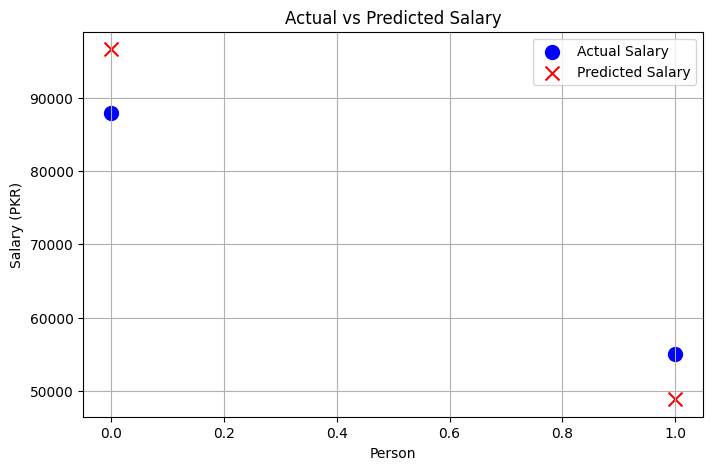

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    color='blue',
    s=100,
    label='Actual Salary'
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    color='red',
    s=100,
    label='Predicted Salary',
    marker='x'
)

plt.xlabel('Person')
plt.ylabel('Salary (PKR)')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.grid(True)
plt.show()

without pipeline

In [ ]:
# ── Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Dataset ──────────────────────────────────────────
data = {
    'Hours':  [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'Salary': [15000, 20000, 25000, 28000, 35000,
               40000, 45000, 48000, 55000, 60000]
}
df = pd.DataFrame(data)

# ── Features and Target ──────────────────────────────
X = df[['Hours']]
y = df['Salary']

# ── Split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Train ─────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Predict ───────────────────────────────────────────
y_pred = model.predict(X_test)

# ── Evaluate ──────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.2%}")

# ── Diagnose ──────────────────────────────────────────
train_score = r2_score(y_train, model.predict(X_train))
test_score  = r2_score(y_test,  model.predict(X_test))

print(f"\nTrain R² : {train_score:.4f}")
print(f"Test  R² : {test_score:.4f}")

if train_score < 0.5:
    print("UNDERFITTING")
elif train_score - test_score > 0.2:
    print("OVERFITTING")
else:
    print("GOOD FIT ✅")
```

---

## The Universal Pattern — Memorize This
```
model = LinearRegression()    # 1. Create
model.fit(X_train, y_train)   # 2. Train
model.predict(X_test)         # 3. Predict

Every sklearn algorithm follows this exact pattern.
Learn it once. Use it forever.